# Data Cleaning 

## Bước 1 Xử lý những Giá trị thiếu (Missing values) và xóa những cột không quan trọng

In [2]:
import pandas as pd 
import numpy as np
# 1. Đọc dữ liệu từ file gốc
df = pd.read_csv('Bangladesh_database_Final_Merged.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4608 entries, 0 to 4607
Data columns (total 61 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area                    4608 non-null   int64  
 1   AP Ratio                4608 non-null   object 
 2   District                4608 non-null   object 
 3   Season                  4608 non-null   object 
 4   Avg Temp                4608 non-null   float64
 5   Avg Humidity            4608 non-null   float64
 6   Crop Name               4608 non-null   object 
 7   Transplant              4608 non-null   object 
 8   Growth                  4608 non-null   object 
 9   Harvest                 4608 non-null   object 
 10  Production              4608 non-null   int64  
 11  Max Temp                4608 non-null   int64  
 12  Min Temp                4608 non-null   float64
 13  Max Relative Humidity   4608 non-null   int64  
 14  Min Relative Humidity   4608 non-null   

In [3]:
df.head()

,Area,AP Ratio,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,...,Temp_Min,Heat_Stress_Days,Wind_Mean,Wind_Max,Wind_Min,Temp_Range,Wind_Range,Rain_Temp_Ratio,Extreme_Heat_Risk,Is_Extreme_Heat
0,259,0.7722007722,Bagerhat,Rabi,17.75,55.0,Wheat,Dec,Jan to March,April,...,8.35,0,1.452917,4.33,0.04,22.23,4.29,11.23,Low Risk,0
1,421,2.247030879,Bagerhat,Rabi,20.50,60.0,Maize 2,Dec,Jan to March,April,...,8.35,0,1.452917,4.33,0.04,22.23,4.29,11.23,Low Risk,0
2,145439,1.847881242,Bagerhat,Rabi,26.00,72.5,Boro,Nov,Dec to March,April,...,8.35,0,1.452917,4.33,0.04,22.23,4.29,11.23,Low Risk,0
3,627,3.50877193,Bagerhat,Rabi,20.50,80.0,Sweet Potato,Nov,Dec to March,April,...,8.35,0,1.452917,4.33,0.04,22.23,4.29,11.23,Low Risk,0
4,383,4.994778068,Bagerhat,Kharif 1,31.50,70.0,Mango,April,No need to do,April to June,...,16.01,54,2.481885,5.86,0.04,25.25,5.82,22.73,High Risk,1


In [3]:
df.describe()

,Area,Avg Temp,Avg Humidity,Production,Max Temp,Min Temp,Max Relative Humidity,Min Relative Humidity,Year,EVI,...,Temp_Max,Temp_Min,Heat_Stress_Days,Wind_Mean,Wind_Max,Wind_Min,Temp_Range,Wind_Range,Rain_Temp_Ratio,Is_Extreme_Heat
count,4608.000000,4608.000000,4608.000000,4.608000e+03,4608.000000,4608.000000,4608.000000,4608.000000,4608.0,4608.000000,...,4608.000000,4608.000000,4608.000000,4608.000000,4608.000000,4608.000000,4608.000000,4608.000000,4608.000000,4608.000000
mean,8084.877604,23.878472,71.597222,1.443418e+04,30.736111,17.020833,61.513889,81.680556,2022.0,0.344988,...,34.932587,14.763767,13.282118,1.979604,6.254019,0.064965,20.168819,6.189054,31.837630,0.235243
std,42154.348588,4.721549,11.245552,6.562959e+04,5.956486,5.407911,12.785919,11.340477,0.0,0.067935,...,4.145008,4.285904,22.313342,0.674624,1.849613,0.037852,4.730191,1.839924,21.745887,0.424197
min,0.000000,11.500000,35.000000,0.000000e+00,15.000000,5.000000,20.000000,45.000000,2022.0,0.114085,...,28.880000,7.090000,0.000000,0.072195,0.510000,0.000000,6.270000,0.510000,3.500000,0.000000
25%,61.000000,20.000000,67.500000,1.197500e+02,25.000000,14.750000,58.000000,78.750000,2022.0,0.306481,...,30.900000,9.620000,0.000000,1.452917,5.100000,0.037500,15.840000,5.010000,10.370000,0.000000
50%,280.000000,25.000000,72.500000,7.260000e+02,30.000000,18.000000,60.000000,85.000000,2022.0,0.334596,...,34.220000,15.500000,0.000000,2.061707,6.320000,0.060000,21.450000,6.220000,35.290000,0.000000
75%,821.250000,27.500000,80.000000,2.881000e+03,35.000000,20.000000,70.000000,90.000000,2022.0,0.386841,...,37.590000,18.340000,17.000000,2.389512,7.370000,0.090000,23.310000,7.320000,45.390000,0.000000
max,663734.000000,34.500000,90.000000,1.077242e+06,47.000000,27.000000,85.000000,100.000000,2022.0,0.594884,...,44.700000,24.880000,96.000000,4.176393,12.920000,0.160000,29.880000,12.870000,120.010000,1.000000


##### Nhận xét lỗi 
1. FPAR có mean ≈ 4.6 (FPAR thường là fraction trong khoảng 0–1) → khả năng lỗi scale (phải là 0–1) hoặc đơn vị khác.  (Fix = sclale lại * 0.1)


#### Xem những bị thiếu những giá trị nào 

In [4]:
pd.set_option('display.max_rows', None)

df.isnull().sum()


Area                      0
AP Ratio                  0
District                  0
Season                    0
Avg Temp                  0
Avg Humidity              0
Crop Name                 0
Transplant                0
Growth                    0
Harvest                   0
Production                0
Max Temp                  0
Min Temp                  0
Max Relative Humidity     0
Min Relative Humidity     0
Year                      0
EVI                       0
LAI                       0
FPAR                      0
LST_Kelvin                0
Soil_Moisture_mm          0
NDVI_Season_Mean          0
NDVI_Season_Max           0
NDVI_Season_Min           0
NDVI_Season_Std           0
NDVI_Season_Range         0
NDVI_Season_CV            0
Avg_Salinity_Index        0
pH                        0
Organic_Carbon            0
Nitrogen                  0
Clay                      0
Sand                      0
Silt                      0
Bulk_Density              0
valid_points        

#### Xóa những cột không liên quan 

In [5]:
# Danh sách các cột đề xuất xóa
cols_to_drop = [
    # 1. Dữ liệu từ file main_data được xác định là weak features
    'Area', 'Avg Temp', 'Harvest', 'Production', 'Max Temp', 
    'Min Temp', 'Max Relative Humidity', 'Min Relative Humidity', 'Year',
    
    # 2. Dữ liệu định danh/vị trí không đóng góp vào mô hình chung (nếu còn sót)
    'grid_log', 'valid_points', 'Latitude', 'Longitude',
    
    # 3. Các cột bị trùng lặp hoặc không cần thiết
    'Temp_Mean', 'Temp_Max', 'Temp_Min', 'Temp_Range', 'Wind_Range'
]

# Thực hiện xóa (dùng errors='ignore' để tránh lỗi)
df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Số lượng cột còn lại: {df.shape[1]}")
print("Các cột đã giữ lại bao gồm các chỉ số quan trọng về Soil, NDVI, Weather và Crop Info.")

Số lượng cột còn lại: 52
Các cột đã giữ lại bao gồm các chỉ số quan trọng về Soil, NDVI, Weather và Crop Info.


## Bước 2 :Xử lý những giá trị trùng lặp 

In [6]:
df = df.drop_duplicates()

## Bước 3 : Xử lý lỗi sai định dạng 

In [7]:


# Giả sử bạn tiếp tục với df đã được xóa dòng lỗi ở bước trước
# df = pd.read_csv('Bangladesh_database_Cleaned_Step1.csv')

# 1. Danh sách các cột phân loại cần chuẩn hóa định dạng chuỗi
categorical_cols = [
    'District', 'Season', 'Crop Name', 'Transplant', 'Growth', 'Harvest', 
    'pH_Suitability', 'Compaction_Risk', 'Dominant_Soil_Texture', 
    'Water_Availability_Cat', 'Extreme_Heat_Risk'
]

for col in categorical_cols:
    if col in df.columns:
        # Xóa khoảng trắng thừa ở đầu/cuối và chuyển về chữ in hoa đầu từ (Capitalize)
        # Việc này giúp tránh trường hợp 'Jashore' và 'Jashore ' bị coi là 2 quận khác nhau
        df[col] = df[col].astype(str).str.strip().str.title()

# 2. Xử lý riêng các cột chu kỳ mùa vụ (thường bị sai định dạng dải tháng)
# Ví dụ: "April to Aug" vs "April-Aug"
date_cols = ['Transplant', 'Growth', 'Harvest']
for col in date_cols:
    if col in df.columns:
        df[col] = df[col].str.replace(' To ', ' to ', case=False)
        df[col] = df[col].str.replace('-', ' to ')

# 3. Ép kiểu dữ liệu số cho các cột tọa độ và chỉ số môi trường 
# (Đảm bảo không còn định dạng 'object' do dữ liệu nhiễu)
numeric_fix_cols = [
    'Avg Temp', 'Avg Humidity', 'Max Temp', 'Min Temp', 
    'Rainfall', 'Wind_Mean', 'pH'
]

for col in numeric_fix_cols:
    if col in df.columns:
        # Chuyển đổi sang số, các giá trị lỗi định dạng không chuyển được sẽ thành NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Xử lý giá trị NaN sau khi ép kiểu (nếu có)
# Điền NaN bằng giá trị trung bình của cột đó để tránh lỗi mô hình
for col in numeric_fix_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# 5. Kiểm tra kết quả
print("Đã chuẩn hóa định dạng cho các cột phân loại và số.")
print(df[categorical_cols].head())

Đã chuẩn hóa định dạng cho các cột phân loại và số.
   District    Season     Crop Name Transplant          Growth        Harvest  \
0  Bagerhat      Rabi         Wheat        Dec  Jan  to  March          April   
1  Bagerhat      Rabi       Maize 2        Dec  Jan  to  March          April   
2  Bagerhat      Rabi          Boro        Nov    Dec to March          April   
3  Bagerhat      Rabi  Sweet Potato        Nov    Dec to March          April   
4  Bagerhat  Kharif 1         Mango      April   No Need to Do  April to June   

     pH_Suitability Compaction_Risk Dominant_Soil_Texture  \
0  Optimal (Tối Ưu)             Low   Loamy (Thịt/Phù Sa)   
1  Optimal (Tối Ưu)             Low   Loamy (Thịt/Phù Sa)   
2  Optimal (Tối Ưu)             Low   Loamy (Thịt/Phù Sa)   
3  Optimal (Tối Ưu)             Low   Loamy (Thịt/Phù Sa)   
4  Optimal (Tối Ưu)             Low   Loamy (Thịt/Phù Sa)   

  Water_Availability_Cat Extreme_Heat_Risk  
0                Optimal          Low Risk  
1   

In [8]:
df.head()

,Area,AP Ratio,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,...,Moisture_Ratio,Water_Availability_Cat,Rainfall,Heat_Stress_Days,Wind_Mean,Wind_Max,Wind_Min,Rain_Temp_Ratio,Extreme_Heat_Risk,Is_Extreme_Heat
0,259,0.7722007722,Bagerhat,Rabi,17.75,55.0,Wheat,Dec,Jan to March,April,...,1.4035,Optimal,220.43,0,1.452917,4.33,0.04,11.23,Low Risk,0
1,421,2.247030879,Bagerhat,Rabi,20.50,60.0,Maize 2,Dec,Jan to March,April,...,1.4035,Optimal,220.43,0,1.452917,4.33,0.04,11.23,Low Risk,0
2,145439,1.847881242,Bagerhat,Rabi,26.00,72.5,Boro,Nov,Dec to March,April,...,1.3611,Optimal,220.43,0,1.452917,4.33,0.04,11.23,Low Risk,0
3,627,3.50877193,Bagerhat,Rabi,20.50,80.0,Sweet Potato,Nov,Dec to March,April,...,1.3611,Optimal,220.43,0,1.452917,4.33,0.04,11.23,Low Risk,0
4,383,4.994778068,Bagerhat,Kharif 1,31.50,70.0,Mango,April,No Need to Do,April to June,...,1.3033,Optimal,656.33,54,2.481885,5.86,0.04,22.73,High Risk,1


## Bước 4: Xử lý những giá trị sai hoặc bất hợp lý (Invaild/incorrect data) 

#### 1. Fix lại lỗi FPAR slale lại do thấy 

In [9]:
print("Mean FPAR trước khi sửa:", df["FPAR"].mean())

df["FPAR"] = df["FPAR"] * 0.1
print("Max FPAR sau khi sửa:", df["FPAR"].mean())

Mean FPAR trước khi sửa: 4.65177987242325
Max FPAR sau khi sửa: 0.46517798724232506


#### 2. Xử lý lỗi #DIV/0! trong cột 'AP Ratio'
Thay thế chuỗi lỗi bằng NaN và chuyển sang kiểu số (float)
Xóa những cột target lỗi 

In [10]:
initial_count = len(df)
df['AP Ratio'] = df['AP Ratio'].replace('#DIV/0!', np.nan)
df['AP Ratio'] = pd.to_numeric(df['AP Ratio'], errors='coerce')
condition_to_drop = (df['Production'] <= 0) | (df['Area'] <= 0) | (df['AP Ratio'].isna())
df = df.drop(df[condition_to_drop].index)
final_count = len(df)
print(f"Số lượng dòng ban đầu: {initial_count}")
print(f"Số lượng dòng đã xóa: {initial_count - final_count}")
print(f"Số lượng dòng còn lại sau khi làm sạch: {final_count}")

Số lượng dòng ban đầu: 4608
Số lượng dòng đã xóa: 429
Số lượng dòng còn lại sau khi làm sạch: 4179


#### Xem Dữ liệu crop name có bao nhiêu loại cây 

In [11]:
df.columns = df.columns.str.strip()

crop_count = df['Crop Name'].value_counts()
print(crop_count)

Crop Name
Boro              64
Sweet Potato      64
Mango             64
Jack Fruit        64
Ripe Papaya       64
Aus               64
Karala            64
Sugarcane         64
Green Papaya      64
Amra              64
Wood Apple        64
Green Coconut     64
Barbati           64
Puishak           64
Palong Shak       64
Garlic            64
Cauliflower       64
Cabbage           64
Boroi             64
Banana            64
Lemon             64
Gourd             64
Betelnut          64
Chalkumra         64
Black Berry       64
Jhinga            64
Lady’S Finger     64
Radish            64
Chili             64
Onion             64
Cucumber          64
Jambura           64
Beans             64
Aman              64
Pumpkin           64
Lal Shak          64
Laushak           64
Danta Shak        64
Danta             64
Guava             64
Rape & Mustard    63
Taramind          63
Kakrol            63
Maize 2           62
Lentil            62
Green Palmyra     62
Sesame            61
Dat

### Xóa giá trị lỗi trong crop name

In [12]:
df = df[df['Crop Name'].str.strip() != '#Ref!']
df['Crop Name'].value_counts()

Crop Name
Boro              64
Sweet Potato      64
Mango             64
Jack Fruit        64
Ripe Papaya       64
Aus               64
Karala            64
Sugarcane         64
Green Papaya      64
Amra              64
Wood Apple        64
Green Coconut     64
Barbati           64
Puishak           64
Palong Shak       64
Garlic            64
Cauliflower       64
Cabbage           64
Boroi             64
Banana            64
Lemon             64
Gourd             64
Betelnut          64
Chalkumra         64
Black Berry       64
Jhinga            64
Lady’S Finger     64
Radish            64
Chili             64
Onion             64
Cucumber          64
Jambura           64
Beans             64
Aman              64
Pumpkin           64
Lal Shak          64
Laushak           64
Danta Shak        64
Danta             64
Guava             64
Rape & Mustard    63
Taramind          63
Kakrol            63
Maize 2           62
Lentil            62
Green Palmyra     62
Sesame            61
Dat

In [13]:
str_cols = df.select_dtypes(include=['object']).columns

for col in str_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: District
<StringArray>
[        'Bagerhat',        'Bandarban',          'Barguna',
         'Barishal',            'Bhola',           'Bogura',
     'Brahmanbaria',         'Chandpur', 'Chapai Nawabganj',
       'Chattogram',        'Chuadanga',        'Coxsbazar',
          'Cumilla',            'Dhaka',         'Dinajpur',
         'Faridpur',             'Feni',        'Gaibandha',
          'Gazipur',        'Gopalganj',         'Habiganj',
         'Jamalpur',          'Jashore',       'Jhallokati',
        'Jhenaidah',        'Joypurhat',      'Khagrachari',
           'Khulna',      'Kishoreganj',         'Kurigram',
          'Kushtia',       'Lakshmipur',      'Lalmonirhat',
        'Madaripur',           'Magura',        'Manikganj',
         'Meherpur',      'Moulvibazar',       'Munshiganj',
       'Mymensingh',          'Naogaon',           'Narail',
      'Narayanganj',        'Narsingdi',           'Natore',
        'Netrokona',       'Nilphamari',         'Noa

C:\Users\ASUS\AppData\Local\Temp\ipykernel_29436\4073995366.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include=['object']).columns


In [14]:




# 2. Định nghĩa các ngưỡng thực tế cho các chỉ số quan trọng
# Các giá trị ngoài khoảng này sẽ được coi là bất hợp lý
valid_ranges = {
    'Avg Temp': (5, 50),      # Nhiệt độ trung bình từ 5°C đến 50°C
    'pH': (3.5, 9.5),         # Độ pH đất nông nghiệp thường từ 3.5 đến 9.5
    'Avg Humidity': (10, 100),# Độ ẩm không khí từ 10% đến 100%
    'Rainfall': (0, 5000),    # Lượng mưa không thể âm
    'LST_Kelvin': (270, 330), # Nhiệt độ bề mặt (tương đương -3°C đến 57°C)
    'Nitrogen': (0, 100),     # Hàm lượng đạm (%)
    'Clay': (0, 100),         # % thành phần đất
    'Sand': (0, 100),
    'Silt': (0, 100)
}

# 3. Hàm xử lý dữ liệu bất hợp lý
def fix_invalid_data(df, ranges):
    df_cleaned = df.copy()
    for col, (min_val, max_val) in ranges.items():
        if col in df_cleaned.columns:
            # Đếm số lượng lỗi trước khi sửa
            invalid_mask = (df_cleaned[col] < min_val) | (df_cleaned[col] > max_val)
            num_invalid = invalid_mask.sum()
            
            if num_invalid > 0:
                print(f"Cột {col}: Phát hiện {num_invalid} giá trị bất hợp lý. Đang xử lý...")
                # Thay thế giá trị sai bằng Median của cột đó để tránh làm lệch dữ liệu
                median_val = df_cleaned[col].median()
                df_cleaned.loc[invalid_mask, col] = median_val
                
    return df_cleaned

# Thực hiện xóa/sửa dữ liệu sai
df_cleaned = fix_invalid_data(df, valid_ranges)

# 4. Kiểm tra logic tổng thành phần đất (Clay + Sand + Silt phải xấp xỉ 100%)
# Nếu tổng sai lệch quá nhiều (> 5%), chúng ta điều chỉnh tỷ lệ
soil_parts = ['Clay', 'Sand', 'Silt']
if all(col in df_cleaned.columns for col in soil_parts):
    soil_sum = df_cleaned[soil_parts].sum(axis=1)
    # Tìm các dòng có tổng sai lệch lớn hơn 1%
    bad_soil_logic = (soil_sum < 99) | (soil_sum > 101)
    if bad_soil_logic.any():
        print(f"Phát hiện {bad_soil_logic.sum()} dòng sai logic tổng thành phần đất. Đang chuẩn hóa...")
        # Chuẩn hóa về tỷ lệ 100%
        df_cleaned.loc[bad_soil_logic, soil_parts] = df_cleaned.loc[bad_soil_logic, soil_parts].div(soil_sum[bad_soil_logic], axis=0) * 100

# 5. Lưu kết quả
print("\n--- Hoàn thành xử lý dữ liệu bất hợp lý ---")



--- Hoàn thành xử lý dữ liệu bất hợp lý ---


In [15]:

import re
import calendar

# ===============================
# COPY DATA
# ===============================
df = df.copy()

# ===============================
# 1. CHUẨN HÓA TOÀN BỘ STRING
# ===============================
str_cols = df.select_dtypes(include="object").columns

for col in str_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

# ===============================
# 2. CHUẨN HÓA TRANSPLANT (FULL MONTH NAME)
# ===============================
month_map = {
    'Jan': 'January', 'Feb': 'February',
    'Aug': 'August', 'Sep': 'September',
    'Oct': 'October', 'Nov': 'November',
    'Dec': 'December'
}

df['Transplant'] = df['Transplant'].replace(month_map)

# ===============================
# 3. FIX TYPO & CHUẨN HÓA TITLE CASE
# ===============================
cycle_cols = ['Transplant', 'Growth', 'Harvest']

df[cycle_cols] = df[cycle_cols].apply(lambda x: x.str.title())

df.replace({
    'Throuout The Year': 'Throughout The Year'
}, inplace=True)

# ===============================
# 4. IMPUTE CROP CYCLE THEO SEASON (VECTORIZE)
# ===============================
season_rules = {
    'Kharif 1': {
        'Transplant': 'March',
        'Growth': 'April To May',
        'Harvest': 'June'
    },
    'Kharif 2': {
        'Transplant': 'July',
        'Growth': 'August To October',
        'Harvest': 'November'
    },
    'Rabi': {
        'Transplant': 'November',
        'Growth': 'December To February',
        'Harvest': 'March'
    }
}

invalid_vals = ['No Need To Do', 'Throughout The Year']

for season, rules in season_rules.items():
    season_mask = df['Season'] == season
    
    for col in cycle_cols:
        invalid_mask = df[col].isin(invalid_vals)
        df.loc[season_mask & invalid_mask, col] = rules[col]

# ===============================
# 5. LOẠI BỎ TIẾNG VIỆT TRONG NGOẶC
# ===============================
df['pH_Suitability'] = df['pH_Suitability'].str.replace(r"\s*\(.*\)", "", regex=True)
df['Dominant_Soil_Texture'] = df['Dominant_Soil_Texture'].str.replace(r"\s*\(.*\)", "", regex=True)

# ===============================
# 6. DROP CỘT KHÔNG CÓ VARIANCE
# ===============================
low_variance_cols = [col for col in df.columns if df[col].nunique() <= 1]
df.drop(columns=low_variance_cols, inplace=True)

# ===============================
# 7. TÍNH THỜI GIAN SINH TRƯỞNG (THÁNG)
# ===============================
month_to_num = {month: index for index, month in enumerate(calendar.month_name) if month}

def duration_months(text):
    if isinstance(text, str) and "To" in text:
        parts = text.split("To")
        if len(parts) == 2:
            start = parts[0].strip()
            end = parts[1].strip()
            if start in month_to_num and end in month_to_num:
                return (month_to_num[end] - month_to_num[start]) % 12
    return np.nan

df['Growth_Duration_Months'] = df['Growth'].apply(duration_months)

# ===============================
# 8. VALIDATION
# ===============================
print("Shape after cleaning:", df.shape)
print("\nDropped columns:", low_variance_cols)
print("\nUnique Seasons:", df['Season'].unique())
print("\nUnique Transplant:", sorted(df['Transplant'].unique()))
print("\nSample Growth Duration:")
print(df[['Growth','Growth_Duration_Months']].head())

C:\Users\ASUS\AppData\Local\Temp\ipykernel_29436\4286739299.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns


Shape after cleaning: (4178, 51)

Dropped columns: ['Year', 'Compaction_Risk']

Unique Seasons: <StringArray>
['Rabi', 'Kharif 1', 'Kharif 2']
Length: 3, dtype: str

Unique Transplant: ['April', 'August', 'December', 'February', 'January', 'July', 'June', 'March', 'May', 'November', 'October', 'September']

Sample Growth Duration:
         Growth  Growth_Duration_Months
0  Jan To March                     NaN
1  Jan To March                     NaN
2  Dec To March                     NaN
3  Dec To March                     NaN
4  April To May                     1.0


In [16]:
str_cols = df.select_dtypes(include=['object']).columns

for col in str_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: District
<StringArray>
[        'Bagerhat',        'Bandarban',          'Barguna',
         'Barishal',            'Bhola',           'Bogura',
     'Brahmanbaria',         'Chandpur', 'Chapai Nawabganj',
       'Chattogram',        'Chuadanga',        'Coxsbazar',
          'Cumilla',            'Dhaka',         'Dinajpur',
         'Faridpur',             'Feni',        'Gaibandha',
          'Gazipur',        'Gopalganj',         'Habiganj',
         'Jamalpur',          'Jashore',       'Jhallokati',
        'Jhenaidah',        'Joypurhat',      'Khagrachari',
           'Khulna',      'Kishoreganj',         'Kurigram',
          'Kushtia',       'Lakshmipur',      'Lalmonirhat',
        'Madaripur',           'Magura',        'Manikganj',
         'Meherpur',      'Moulvibazar',       'Munshiganj',
       'Mymensingh',          'Naogaon',           'Narail',
      'Narayanganj',        'Narsingdi',           'Natore',
        'Netrokona',       'Nilphamari',         'Noa

C:\Users\ASUS\AppData\Local\Temp\ipykernel_29436\4073995366.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include=['object']).columns


##### Fix lỗi NDVI_Season_Mean: 20 negative (nhỏ, ~ -0.02).
Giải thích: Chỉ số NDVI (độ xanh của lá) về mặt vật lý chỉ nằm trong khoảng 0 đến 1 đối với thực vật. Giá trị âm thường chỉ xuất hiện ở vùng mặt nước hoặc do lỗi cảm biến vệ tinh bị mây che.             (Hướng xử lý clip về  0) 
NDVI_Season_Min: 64 negative (tương tự). 

In [17]:
df['NDVI_Season_Mean'] = df['NDVI_Season_Mean'].clip(lower=0)
df['NDVI_Season_Min'] = df['NDVI_Season_Min'].clip(lower=0)


##### Fix lỗi Đảo ngược Max Humidlity và Min Humidlity 


In [18]:
df[['Max Relative Humidity', 'Min Relative Humidity']] = df[['Min Relative Humidity', 'Max Relative Humidity']]

##### Fix Thành phần đất (Clay + Sand + Silt) không chính xác bằng 100%

In [19]:
total = df[['Clay','Sand','Silt']].sum(axis=1)
df['Clay'] = df['Clay'] / total * 100
df['Sand'] = df['Sand'] / total * 100
df['Silt'] = df['Silt'] / total * 100

##### Đổi đơn vị thành độ C

In [20]:
df['LST_C'] = df['LST_Kelvin'] - 273.15
df.drop(columns=['LST_Kelvin'], inplace=True)

## Bước 5 : Xử lý những giá trị ngoại lai

In [21]:


def smart_agri_cleaner(df, capping_cols, extreme_event_cols):
    """
    Xử lý Outliers thông minh cho dữ liệu Nông nghiệp.
    - capping_cols: Các cột chỉ cần giới hạn biên (EVI, LAI, Dinh dưỡng đất).
    - extreme_event_cols: Các cột thời tiết cần đánh dấu thiên tai trước khi xử lý.
    """
    df_final = df.copy()
    
    # 1. Xử lý nhóm Biến Khí hậu (Cần đánh dấu trước khi Cap)
    for col in extreme_event_cols:
        if col in df_final.columns:
            Q1 = df_final[col].quantile(0.25)
            Q3 = df_final[col].quantile(0.75)
            IQR = Q3 - Q1
            upper_bound = Q3 + 1.5 * IQR
            
            # Tạo cột Flag: 1 nếu là thiên tai/cực đoan, 0 nếu bình thường
            df_final[f'is_extreme_{col}'] = (df_final[col] > upper_bound).astype(int)
            
            # Sau đó mới thực hiện Capping để ổn định phương sai cho mô hình
            df_final[col] = np.clip(df_final[col], None, upper_bound)
            print(f"[v] Đã Flag và Cap cột cực đoan: {col}")

    # 2. Xử lý nhóm Biến Chỉ số & Đất (Capping thông thường)
    for col in capping_cols:
        if col in df_final.columns:
            Q1 = df_final[col].quantile(0.25)
            Q3 = df_final[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Sử dụng np.clip để code gọn và nhanh hơn np.where
            df_final[col] = np.clip(df_final[col], lower_bound, upper_bound)
    
    print(f"[-] Hoàn thành xử lý {len(capping_cols) + len(extreme_event_cols)} cột.")
    return df_final

# --- ÁP DỤNG VÀO DỮ LIỆU CỦA BẠN ---

# Nhóm 1: Các biến chỉ số (Vệ tinh, Đất, Độ ẩm) - Dùng Capping
capping_list = [
     'Nitrogen', 'LAI', 'Organic_Carbon',
    'Max Relative Humidity', 'Min Relative Humidity', 'Avg Humidity', 'EVI', 'FPAR'
]

# Nhóm 2: Các biến có tính "Thiên tai/Cực đoan" - Dùng Flagging + Capping
extreme_list = ['Heat_Stress_Days', 'Wind_Max']

# Thực hiện xử lý
df = smart_agri_cleaner(df, capping_list, extreme_list)
df.to_csv('Agri_Data_Cleaned.csv', index=False, encoding='utf-8-sig')

[v] Đã Flag và Cap cột cực đoan: Heat_Stress_Days
[v] Đã Flag và Cap cột cực đoan: Wind_Max
[-] Hoàn thành xử lý 10 cột.


In [22]:
df.head()

,Area,AP Ratio,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,...,Wind_Mean,Wind_Max,Wind_Min,Rain_Temp_Ratio,Extreme_Heat_Risk,Is_Extreme_Heat,Growth_Duration_Months,LST_C,is_extreme_Heat_Stress_Days,is_extreme_Wind_Max
0,259,0.772201,Bagerhat,Rabi,17.75,55.0,Wheat,December,Jan To March,April,...,1.452917,4.33,0.04,11.23,Low Risk,0,NaN,24.144525,0,0
1,421,2.247031,Bagerhat,Rabi,20.50,60.0,Maize 2,December,Jan To March,April,...,1.452917,4.33,0.04,11.23,Low Risk,0,NaN,24.144525,0,0
2,145439,1.847881,Bagerhat,Rabi,26.00,72.5,Boro,November,Dec To March,April,...,1.452917,4.33,0.04,11.23,Low Risk,0,NaN,24.144525,0,0
3,627,3.508772,Bagerhat,Rabi,20.50,80.0,Sweet Potato,November,Dec To March,April,...,1.452917,4.33,0.04,11.23,Low Risk,0,NaN,24.144525,0,0
4,383,4.994778,Bagerhat,Kharif 1,31.50,70.0,Mango,April,April To May,April To June,...,2.481885,5.86,0.04,22.73,High Risk,1,1.0,28.431973,1,0


#### tạo ra cột Yeild và xóa bỏ drop bỏ những cột Growth   

In [23]:
df = df.drop('Growth_Duration_Months', axis=1)
df = df.drop('Wind_Min', axis=1)
df = df.drop('AP Ratio',axis =1)
df['Yield'] = df['Production'] / df['Area']

In [24]:
df.info()

<class 'pandas.DataFrame'>
Index: 4178 entries, 0 to 4607
Data columns (total 51 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Area                         4178 non-null   int64  
 1   District                     4178 non-null   str    
 2   Season                       4178 non-null   str    
 3   Avg Temp                     4178 non-null   float64
 4   Avg Humidity                 4178 non-null   float64
 5   Crop Name                    4178 non-null   str    
 6   Transplant                   4178 non-null   str    
 7   Growth                       4178 non-null   str    
 8   Harvest                      4178 non-null   str    
 9   Production                   4178 non-null   int64  
 10  Max Temp                     4178 non-null   int64  
 11  Min Temp                     4178 non-null   float64
 12  Max Relative Humidity        4178 non-null   int64  
 13  Min Relative Humidity        4178 

##### Xem giá trị ngoại lai của yeild 

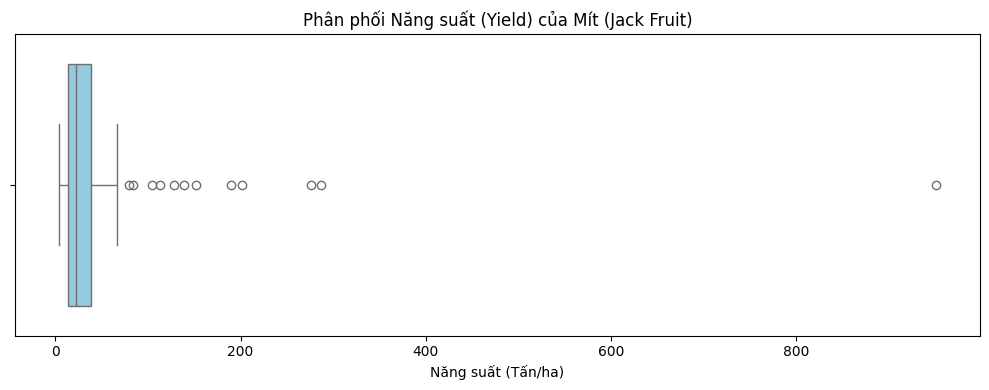

Ngưỡng trên an toàn của Box Plot là: 75.25
Số lượng ngoại lệ phát hiện: 12

Danh sách các ngoại lệ bị bắt:
      Production  Area       Yield
725         5560    70   79.428571
2597        9716   116   83.758621
3533       26144   250  104.576000
1589       11311   100  113.110000
2021       25718   200  128.590000
437        20907   150  139.380000
4181       12164    80  152.050000
3317       32199   170  189.405882
4253       18969    94  201.797872
2165       82756   300  275.853333
1517       28681   100  286.810000
3245       57073    60  951.216667


In [25]:

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tải dữ liệu và lọc riêng Mít (Jack Fruit)

jf_data = df[df['Crop Name'] == 'Jack Fruit']

# 2. Vẽ biểu đồ Box Plot để quan sát bằng mắt
plt.figure(figsize=(10, 4))
sns.boxplot(x=jf_data['Yield'], color='skyblue')
plt.title('Phân phối Năng suất (Yield) của Mít (Jack Fruit)')
plt.xlabel('Năng suất (Tấn/ha)')
plt.tight_layout()
plt.savefig('jackfruit_boxplot.png') # Lưu ảnh
plt.show()

# 3. Tính toán các ngưỡng để lọc tự động
Q1 = jf_data['Yield'].quantile(0.25)
Q3 = jf_data['Yield'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Trích xuất các dòng là Ngoại lệ (Outliers)
outliers = jf_data[(jf_data['Yield'] < lower_bound) | (jf_data['Yield'] > upper_bound)]

print(f"Ngưỡng trên an toàn của Box Plot là: {upper_bound:.2f}")
print(f"Số lượng ngoại lệ phát hiện: {len(outliers)}")
print("\nDanh sách các ngoại lệ bị bắt:")
print(outliers[['Production', 'Area', 'Yield']].sort_values('Yield'))

In [26]:



# 2. Tính toán ngưỡng ngoại lệ của Box Plot cho riêng Jack Fruit
jf_data = df[df['Crop Name'] == 'Jack Fruit']
Q1 = jf_data['Yield'].quantile(0.25)
Q3 = jf_data['Yield'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Ngưỡng trên (Upper Bound) của Jack Fruit: {upper_bound:.2f}")

# 3. Lọc ra các dòng ngoại lệ của Jack Fruit vượt ngưỡng trên trong DataFrame chính
outlier_condition = (df['Crop Name'] == 'Jack Fruit') & (df['Yield'] > upper_bound)
print(f"Số lượng dòng ngoại lệ phát hiện và chuẩn bị sửa: {outlier_condition.sum()}")
df['Production'] = df['Production'].astype(float)
# 4. Sửa lỗi: Giảm Production đi 100 lần cho các dòng này
df.loc[outlier_condition, 'Production'] = df.loc[outlier_condition, 'Production'] / 100

# 5. Cập nhật lại Yield và AP Ratio theo Production mới
df.loc[outlier_condition, 'Yield'] = df.loc[outlier_condition, 'Production'] / df.loc[outlier_condition, 'Area']
df.loc[outlier_condition, 'AP Ratio'] = df.loc[outlier_condition, 'Yield']

# 6. Kiểm tra qua một số dòng sau khi sửa
print("\n--- Dữ liệu của các dòng lỗi sau khi được sửa (chia 100) ---")
print(df.loc[outlier_condition, ['Crop Name', 'Area', 'Production', 'Yield']])



Ngưỡng trên (Upper Bound) của Jack Fruit: 75.25
Số lượng dòng ngoại lệ phát hiện và chuẩn bị sửa: 12

--- Dữ liệu của các dòng lỗi sau khi được sửa (chia 100) ---
       Crop Name  Area  Production     Yield
437   Jack Fruit   150      209.07  1.393800
725   Jack Fruit    70       55.60  0.794286
1517  Jack Fruit   100      286.81  2.868100
1589  Jack Fruit   100      113.11  1.131100
2021  Jack Fruit   200      257.18  1.285900
2165  Jack Fruit   300      827.56  2.758533
2597  Jack Fruit   116       97.16  0.837586
3245  Jack Fruit    60      570.73  9.512167
3317  Jack Fruit   170      321.99  1.894059
3533  Jack Fruit   250      261.44  1.045760
4181  Jack Fruit    80      121.64  1.520500
4253  Jack Fruit    94      189.69  2.017979


In [27]:
df = df.drop('AP Ratio',axis =1)


In [ ]:
df = df.drop('')

In [28]:
df.to_csv('Agri_Data_Cleaned.csv', index=False, encoding='utf-8-sig')